In [70]:
# =============================================================================
# Compare Kafka runs with different POLL_MAX_MSG
# Metrics: throughput, latency, lag, CPU, memory, SLO violations
# =============================================================================

from pathlib import Path
import glob
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Put each run folder here
# ---------------------------------------------------------------------

RUN_DIRS = [
    Path("../results/20260508_033947_balanced"),  # example poll 5 , FETCH_MAX_WAIT_MS: "20"
    Path("../results/20260508_031721_balanced"),  # example poll 10, FETCH_MAX_WAIT_MS: "20"
    Path("../results/20260508_023438_balanced"),  # example poll 25, FETCH_MAX_WAIT_MS: "20"
    Path("../results/20260508_015422_balanced"),  # example poll 50, FETCH_MAX_WAIT_MS: "20"
    Path("../results/20260507_233056_balanced"),  # example poll 200, FETCH_MAX_WAIT_MS: "20"
    Path("../results/20260508_044659_balanced"),  # example poll 20 , FETCH_MAX_WAIT_MS: "5" , compression type = none
]

OUTPUT_DIR = Path("./poll_max_msg_comparison")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(exist_ok=True, parents=True)
TABLE_DIR.mkdir(exist_ok=True, parents=True)

BUCKET_SEC = 5
PER_MSG_SAMPLE_RATE_DEFAULT = 0.05

In [71]:
# =============================================================================
# 2. Helper functions
# =============================================================================

def read_many_csv(run_dir, prefix):
    """
    Read CSV files from this exact structure:

    run_dir/
      consumer/
        consumer-sts-0_metrics/
          2026-05-08-02-52/
            per_message_latency_2026-05-08-02-52_consumer-sts-0.csv
        consumer-sts-1_metrics/
          2026-05-08-02-52/
            ...

    Example:
        read_many_csv(run_dir, "per_message_latency")
        read_many_csv(run_dir, "consumer_metrics")
        read_many_csv(run_dir, "consumer_partition_lag")
    """

    from pathlib import Path
    import pandas as pd

    run_dir = Path(run_dir)

    search_pattern = (
        run_dir
        / "consumer"
        / "consumer-sts-*_metrics"
        / "*"
        / f"{prefix}_*.csv"
    )

    files = sorted(search_pattern.parent.glob(search_pattern.name))

    # The line above may not expand all wildcards correctly with Path objects,
    # so use glob from the standard library for full wildcard expansion.
    import glob

    files = sorted(glob.glob(str(search_pattern)))

    #print(f"\n[INFO] Searching with exact pattern:")
    #print(search_pattern)
    #print(f"[INFO] Found {len(files)} files")

    #for f in files[:10]:
    #    print("   ", f)

    if not files:
        return pd.DataFrame()

    dfs = []

    for f in files:
        try:
            path = Path(f)
            df = pd.read_csv(path)
            df["source_file"] = path.name
            df["source_path"] = str(path)
            df["source_pod"] = path.parts[-3].replace("_metrics", "")
            df["source_run_folder"] = path.parts[-2]
            dfs.append(df)

        except Exception as e:
            print(f"[WARN] Failed reading {f}: {e}")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)

    print(f"[OK] Loaded rows: {len(out)}")

    return out


def read_config(run_dir):
    """
    Reads pipeline-configmap.yaml and returns cfg['data'].
    """
    paths = list(run_dir.glob("**/pipeline-configmap.yaml"))

    if not paths:
        return {}

    config_path = paths[0]

    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    return cfg.get("data", {})


def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def q(s, p):
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) == 0:
        return np.nan

    return float(s.quantile(p))


def cv(s):
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) == 0:
        return np.nan

    mean = s.mean()

    if mean == 0:
        return np.nan

    return float(s.std() / mean)


def safe_int(cfg, key, default=np.nan):
    try:
        return int(cfg.get(key, default))
    except Exception:
        return default


def safe_float(cfg, key, default=np.nan):
    try:
        return float(cfg.get(key, default))
    except Exception:
        return default

In [72]:
# =============================================================================
# 3. Analyze one run
# =============================================================================

def analyze_one_run(run_dir):
    cfg = read_config(run_dir)

    poll_max_msg = safe_int(cfg, "POLL_MAX_MSG")
    target_rate = safe_float(cfg, "TARGET_RATE")
    fetch_wait = safe_int(cfg, "FETCH_MAX_WAIT_MS")
    fetch_min_bytes = safe_int(cfg, "FETCH_MIN_BYTES")
    traffic_mode = cfg.get("TRAFFIC_MODE", "unknown")
    sample_rate = safe_float(cfg, "PER_MSG_LAT_SAMPLE_RATE", PER_MSG_SAMPLE_RATE_DEFAULT)

    metrics_df = read_many_csv(run_dir, "consumer_metrics")
    lag_df = read_many_csv(run_dir, "consumer_partition_lag")
    per_msg_df = read_many_csv(run_dir, "per_message_latency")
    rebalance_df = read_many_csv(run_dir, "consumer_rebalance_events")

    metrics_df = to_num(
        metrics_df,
        [
            "uptime_sec",
            "consumed_total",
            "lat_p95_ms",
            "lat_p99_ms",
            "window_total",
            "window_viol",
            "total_lag",
            "max_lag",
            "lag_skew_ratio",
            "cpu_percent",
            "mem_percent",
            "assigned_partitions",
        ],
    )

    lag_df = to_num(
        lag_df,
        [
            "ts_epoch",
            "partition",
            "current_offset",
            "high_watermark",
            "lag",
        ],
    )

    per_msg_df = to_num(
        per_msg_df,
        [
            "recv_ts",
            "producer_ts",
            "e2e_ms",
            "partition",
            "offset",
            "index",
        ],
    )

    # ------------------------------------------------------------
    # Correct throughput from consumed_total delta
    # ------------------------------------------------------------
    metrics_fixed = metrics_df.copy()

    if not metrics_fixed.empty and {"pod", "uptime_sec", "consumed_total"}.issubset(metrics_fixed.columns):
        metrics_fixed = metrics_fixed.sort_values(["pod", "uptime_sec"])

        metrics_fixed["delta_msgs"] = (
            metrics_fixed
            .groupby("pod")["consumed_total"]
            .diff()
        )

        metrics_fixed["delta_time"] = (
            metrics_fixed
            .groupby("pod")["uptime_sec"]
            .diff()
        )

        metrics_fixed["true_msg_rate"] = (
            metrics_fixed["delta_msgs"] /
            metrics_fixed["delta_time"]
        )

        metrics_fixed = metrics_fixed[
            (metrics_fixed["delta_msgs"] > 0) &
            (metrics_fixed["delta_time"] > 0)
        ].copy()

    else:
        metrics_fixed["true_msg_rate"] = np.nan

    # ------------------------------------------------------------
    # Per-message latency summary
    # ------------------------------------------------------------
    if not per_msg_df.empty and "e2e_ms" in per_msg_df.columns:
        lat_p50 = q(per_msg_df["e2e_ms"], 0.50)
        lat_p90 = q(per_msg_df["e2e_ms"], 0.90)
        lat_p95 = q(per_msg_df["e2e_ms"], 0.95)
        lat_p99 = q(per_msg_df["e2e_ms"], 0.99)
        lat_p999 = q(per_msg_df["e2e_ms"], 0.999)
        lat_max = per_msg_df["e2e_ms"].max()
        tail_amp = lat_p99 / lat_p50 if lat_p50 and lat_p50 > 0 else np.nan
    else:
        lat_p50 = lat_p90 = lat_p95 = lat_p99 = lat_p999 = lat_max = tail_amp = np.nan

    # ------------------------------------------------------------
    # Window p99 summary
    # ------------------------------------------------------------
    valid_p99 = metrics_fixed.dropna(subset=["lat_p99_ms"]) if "lat_p99_ms" in metrics_fixed.columns else pd.DataFrame()

    # ------------------------------------------------------------
    # Throughput summary
    # ------------------------------------------------------------
    valid_thr = metrics_fixed.dropna(subset=["true_msg_rate"]) if "true_msg_rate" in metrics_fixed.columns else pd.DataFrame()

    # ------------------------------------------------------------
    # Lag summary
    # ------------------------------------------------------------
    if not lag_df.empty and "lag" in lag_df.columns:
        lag_mean = lag_df["lag"].mean()
        lag_p95 = q(lag_df["lag"], 0.95)
        lag_p99 = q(lag_df["lag"], 0.99)
        lag_max = lag_df["lag"].max()
        lag_nonzero_fraction = (lag_df["lag"] > 0).mean()
        partitions_seen = lag_df["partition"].nunique()
    else:
        lag_mean = lag_p95 = lag_p99 = lag_max = lag_nonzero_fraction = partitions_seen = np.nan

    # ------------------------------------------------------------
    # CPU / memory
    # ------------------------------------------------------------
    cpu_mean = metrics_df["cpu_percent"].mean() if "cpu_percent" in metrics_df.columns else np.nan
    cpu_max = metrics_df["cpu_percent"].max() if "cpu_percent" in metrics_df.columns else np.nan
    mem_mean = metrics_df["mem_percent"].mean() if "mem_percent" in metrics_df.columns else np.nan
    mem_max = metrics_df["mem_percent"].max() if "mem_percent" in metrics_df.columns else np.nan

    # ------------------------------------------------------------
    # SLO violation from window_total/window_viol
    # ------------------------------------------------------------
    if {"window_total", "window_viol"}.issubset(metrics_df.columns):
        total_window = metrics_df["window_total"].sum()
        total_viol = metrics_df["window_viol"].sum()
        slo_violation_rate = total_viol / total_window if total_window > 0 else np.nan
    else:
        slo_violation_rate = np.nan

    # ------------------------------------------------------------
    # Per-partition fairness
    # ------------------------------------------------------------
    if not per_msg_df.empty and {"partition", "e2e_ms"}.issubset(per_msg_df.columns):
        part_lat = (
            per_msg_df
            .groupby("partition")
            .agg(
                part_msg_samples=("e2e_ms", "size"),
                part_p99_ms=("e2e_ms", lambda x: x.quantile(0.99)),
            )
            .reset_index()
        )

        partition_p99_cv = cv(part_lat["part_p99_ms"])
        partition_msg_count_cv = cv(part_lat["part_msg_samples"])
    else:
        partition_p99_cv = np.nan
        partition_msg_count_cv = np.nan

    if not lag_df.empty and {"partition", "lag"}.issubset(lag_df.columns):
        part_lag = (
            lag_df
            .groupby("partition")
            .agg(
                part_lag_mean=("lag", "mean"),
                part_lag_max=("lag", "max"),
            )
            .reset_index()
        )

        partition_lag_mean_cv = cv(part_lag["part_lag_mean"])
    else:
        partition_lag_mean_cv = np.nan

    row = {
        "run_dir": str(run_dir),
        "traffic_mode": traffic_mode,
        "poll_max_msg": poll_max_msg,
        "target_rate": target_rate,
        "fetch_max_wait_ms": fetch_wait,
        "fetch_min_bytes": fetch_min_bytes,
        "consumer_pods": metrics_df["pod"].nunique() if "pod" in metrics_df.columns else np.nan,
        "partitions_seen": partitions_seen,
        "rebalance_events": len(rebalance_df),

        # True per-message latency
        "sampled_messages": len(per_msg_df),
        "lat_p50_ms": lat_p50,
        "lat_p90_ms": lat_p90,
        "lat_p95_ms": lat_p95,
        "lat_p99_ms": lat_p99,
        "lat_p999_ms": lat_p999,
        "lat_max_ms": lat_max,
        "tail_amp_p99_p50": tail_amp,

        # Window p99 behavior
        "window_p99_mean_ms": valid_p99["lat_p99_ms"].mean() if not valid_p99.empty else np.nan,
        "window_p99_std_ms": valid_p99["lat_p99_ms"].std() if not valid_p99.empty else np.nan,
        "window_p99_max_ms": valid_p99["lat_p99_ms"].max() if not valid_p99.empty else np.nan,

        # Corrected throughput
        "throughput_mean_msg_s": valid_thr["true_msg_rate"].mean() if not valid_thr.empty else np.nan,
        "throughput_median_msg_s": valid_thr["true_msg_rate"].median() if not valid_thr.empty else np.nan,
        "throughput_std_msg_s": valid_thr["true_msg_rate"].std() if not valid_thr.empty else np.nan,
        "throughput_max_msg_s": valid_thr["true_msg_rate"].max() if not valid_thr.empty else np.nan,
        "throughput_cv": cv(valid_thr["true_msg_rate"]) if not valid_thr.empty else np.nan,

        # Lag
        "lag_mean": lag_mean,
        "lag_p95": lag_p95,
        "lag_p99": lag_p99,
        "lag_max": lag_max,
        "lag_nonzero_fraction": lag_nonzero_fraction,

        # CPU/memory
        "cpu_mean_percent": cpu_mean,
        "cpu_max_percent": cpu_max,
        "mem_mean_percent": mem_mean,
        "mem_max_percent": mem_max,

        # SLO
        "slo_violation_rate": slo_violation_rate,

        # Fairness
        "partition_p99_cv": partition_p99_cv,
        "partition_msg_count_cv": partition_msg_count_cv,
        "partition_lag_mean_cv": partition_lag_mean_cv,
    }

    return row, metrics_fixed, lag_df, per_msg_df

In [73]:
# =============================================================================
# 4. Run comparison across all folders
# =============================================================================

rows = []
all_metrics_fixed = {}

for run_dir in RUN_DIRS:
    print(f"Analyzing: {run_dir}")

    row, metrics_fixed, lag_df, per_msg_df = analyze_one_run(run_dir)

    poll = row["poll_max_msg"]

    rows.append(row)
    all_metrics_fixed[poll] = metrics_fixed

comparison_df = pd.DataFrame(rows)

comparison_df = comparison_df.sort_values("poll_max_msg")

#comparison_df

Analyzing: ../results/20260508_033947_balanced
[OK] Loaded rows: 36
[OK] Loaded rows: 10370
[OK] Loaded rows: 7625
[OK] Loaded rows: 6
Analyzing: ../results/20260508_031721_balanced
[OK] Loaded rows: 37
[OK] Loaded rows: 39661
[OK] Loaded rows: 7468
[OK] Loaded rows: 44
Analyzing: ../results/20260508_023438_balanced
[OK] Loaded rows: 162
[OK] Loaded rows: 24160
[OK] Loaded rows: 7490
[OK] Loaded rows: 6
Analyzing: ../results/20260508_015422_balanced
[OK] Loaded rows: 174
[OK] Loaded rows: 25680
[OK] Loaded rows: 7598
[OK] Loaded rows: 6
Analyzing: ../results/20260507_233056_balanced
[OK] Loaded rows: 264
[OK] Loaded rows: 38722
[OK] Loaded rows: 54614
[OK] Loaded rows: 47
Analyzing: ../results/20260508_044659_balanced
[OK] Loaded rows: 36
[OK] Loaded rows: 75070
[OK] Loaded rows: 7419
[OK] Loaded rows: 6


In [74]:
# =============================================================================
# 5. Save comparison table
# =============================================================================

comparison_df.to_csv(
    TABLE_DIR / "poll_max_msg_comparison_summary.csv",
    index=False
)

comparison_df.round(3)

,run_dir,traffic_mode,poll_max_msg,target_rate,fetch_max_wait_ms,fetch_min_bytes,consumer_pods,partitions_seen,rebalance_events,sampled_messages,...,lag_max,lag_nonzero_fraction,cpu_mean_percent,cpu_max_percent,mem_mean_percent,mem_max_percent,slo_violation_rate,partition_p99_cv,partition_msg_count_cv,partition_lag_mean_cv
0,../results/20260508_033947_balanced,balanced,5,1500.0,20,1,6,60,6,7625,...,44,0.208,13.656,38.6,16.369,31.9,0.114,0.395,0.088,0.589
1,../results/20260508_031721_balanced,balanced,10,1500.0,20,1,6,60,44,7468,...,27,0.050,13.538,50.0,16.551,31.6,0.112,0.403,0.094,0.571
5,../results/20260508_044659_balanced,balanced,20,1500.0,5,1,6,60,6,7419,...,13,0.015,13.047,50.0,16.783,33.2,0.124,0.386,0.092,0.566
2,../results/20260508_023438_balanced,balanced,25,1500.0,20,1,6,60,6,7490,...,20,0.083,13.207,50.0,16.477,32.0,0.147,0.331,0.092,0.563
3,../results/20260508_015422_balanced,balanced,50,1500.0,20,1,6,60,6,7598,...,37,0.078,13.659,50.0,16.451,31.6,0.229,0.456,0.090,0.584
4,../results/20260507_233056_balanced,balanced,200,1500.0,20,1,6,60,47,54614,...,214,0.181,16.164,50.0,16.576,31.6,0.280,0.355,0.034,0.590


In [75]:
# =============================================================================
# 6. Key compact table for paper/report
# =============================================================================

paper_table = comparison_df[
    [
        "poll_max_msg",
        "target_rate",
        "throughput_mean_msg_s",
        "throughput_cv",
        "lat_p50_ms",
        "lat_p95_ms",
        "lat_p99_ms",
        "lat_p999_ms",
        "window_p99_mean_ms",
        "window_p99_std_ms",
        "window_p99_max_ms",
        "lag_mean",
        "lag_max",
        "lag_nonzero_fraction",
        "cpu_mean_percent",
        "cpu_max_percent",
        "slo_violation_rate",
        "tail_amp_p99_p50",
    ]
].copy()

paper_table = paper_table.round(3)

paper_table.to_csv(
    TABLE_DIR / "poll_max_msg_paper_table.csv",
    index=False
)

paper_table

,poll_max_msg,target_rate,throughput_mean_msg_s,throughput_cv,lat_p50_ms,lat_p95_ms,lat_p99_ms,lat_p999_ms,window_p99_mean_ms,window_p99_std_ms,window_p99_max_ms,lag_mean,lag_max,lag_nonzero_fraction,cpu_mean_percent,cpu_max_percent,slo_violation_rate,tail_amp_p99_p50
0,5,1500.0,139.580,0.645,13.839,734.971,2380.968,3863.876,1672.665,1252.376,3856.074,0.397,44,0.208,13.656,38.6,0.114,172.042
1,10,1500.0,135.908,0.705,26.546,427.930,1407.755,2221.459,1194.201,464.551,1951.016,0.089,27,0.050,13.538,50.0,0.112,53.031
5,20,1500.0,139.684,0.705,49.245,528.919,1926.288,2993.718,1128.364,818.098,2877.105,0.021,13,0.015,13.047,50.0,0.124,39.116
2,25,1500.0,149.384,0.654,55.814,262.217,819.875,1525.079,648.624,166.146,1061.416,0.150,20,0.083,13.207,50.0,0.147,14.689
3,50,1500.0,134.305,0.716,66.795,590.144,1908.369,3525.970,1523.792,890.309,3427.402,0.145,37,0.078,13.659,50.0,0.229,28.571
4,200,1500.0,137.997,0.208,71.195,883.983,6314.606,14697.500,1988.056,2924.619,15912.276,0.849,214,0.181,16.164,50.0,0.280,88.695


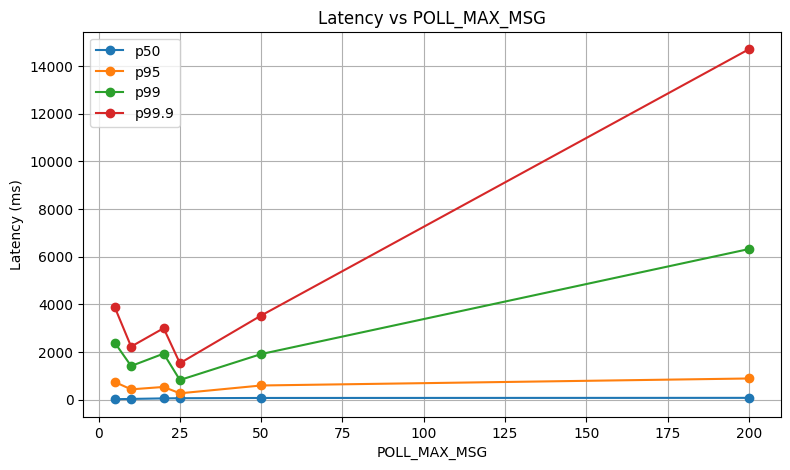

In [76]:
# =============================================================================
# 7. Plot: POLL_MAX_MSG vs latency
# =============================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lat_p50_ms"],
    marker="o",
    label="p50"
)

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lat_p95_ms"],
    marker="o",
    label="p95"
)

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lat_p99_ms"],
    marker="o",
    label="p99"
)

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lat_p999_ms"],
    marker="o",
    label="p99.9"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("Latency (ms)")
plt.title("Latency vs POLL_MAX_MSG")
plt.legend()
plt.grid(True)

plt.savefig(
    FIG_DIR / "latency_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

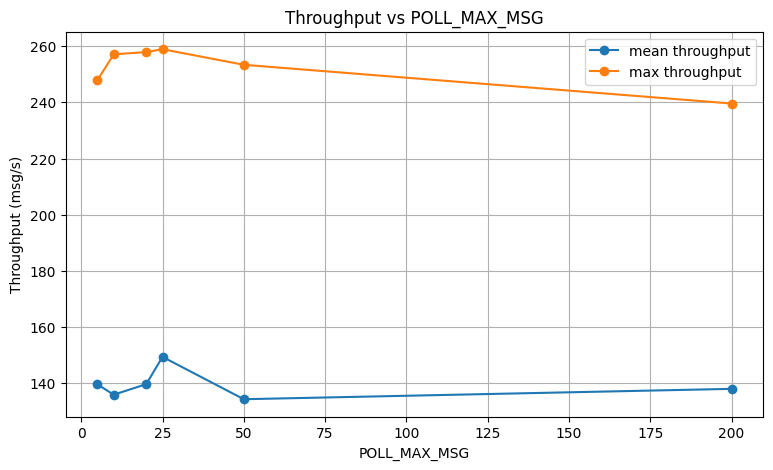

In [77]:
# =============================================================================
# 8. Plot: POLL_MAX_MSG vs throughput
# =============================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["throughput_mean_msg_s"],
    marker="o",
    label="mean throughput"
)

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["throughput_max_msg_s"],
    marker="o",
    label="max throughput"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("Throughput (msg/s)")
plt.title("Throughput vs POLL_MAX_MSG")
plt.legend()
plt.grid(True)

plt.savefig(
    FIG_DIR / "throughput_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

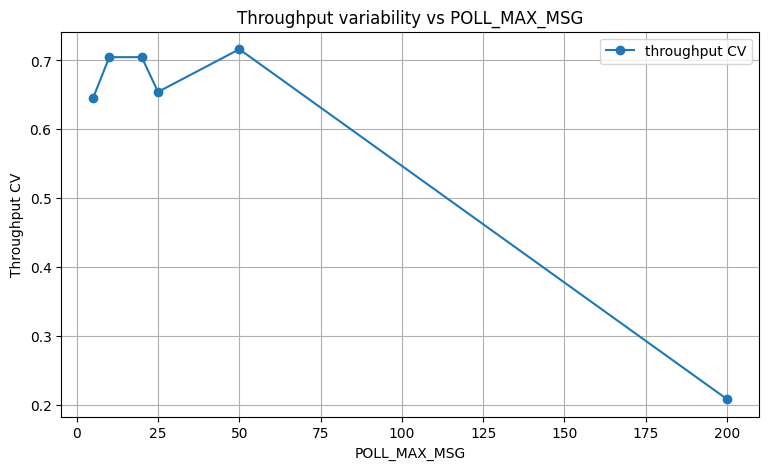

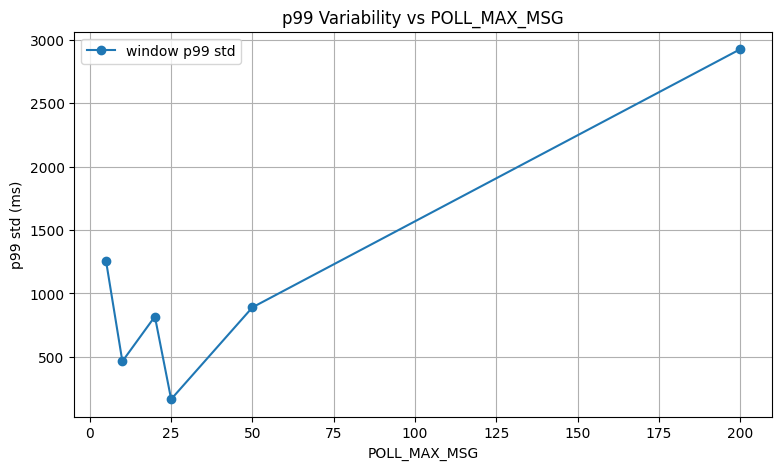

In [79]:
# =============================================================================
# 9. Plot: Throughput CV and p99 std
# =============================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["throughput_cv"],
    marker="o",
    label="throughput CV"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("Throughput CV")
plt.title("Throughput variability vs POLL_MAX_MSG")
plt.legend()
plt.grid(True)

plt.savefig(
    FIG_DIR / "throughput_cv_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["window_p99_std_ms"],
    marker="o",
    label="window p99 std"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("p99 std (ms)")
plt.title("p99 Variability vs POLL_MAX_MSG")
plt.legend()
plt.grid(True)

plt.savefig(
    FIG_DIR / "p99_std_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

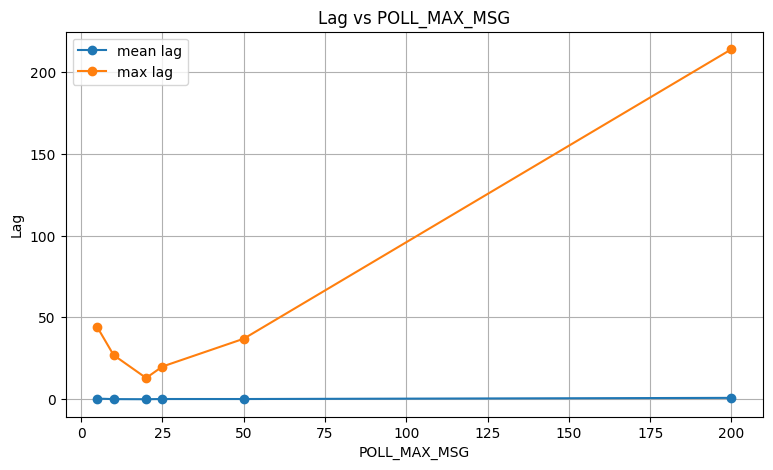

In [81]:
# =============================================================================
# 10. Plot: Lag vs POLL_MAX_MSG
# =============================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lag_mean"],
    marker="o",
    label="mean lag"
)

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["lag_max"],
    marker="o",
    label="max lag"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("Lag")
plt.title("Lag vs POLL_MAX_MSG")
plt.legend()
plt.grid(True)

plt.savefig(
    FIG_DIR / "lag_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

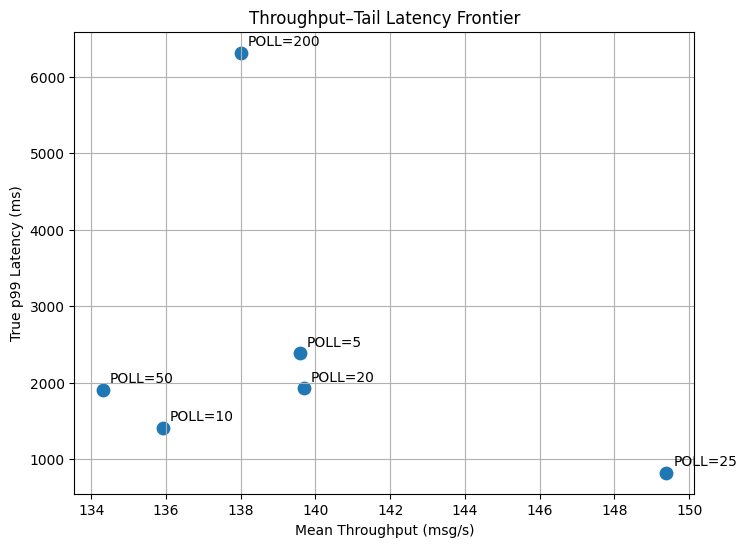

In [82]:
# =============================================================================
# 11. Plot: Throughput-latency tradeoff frontier
# =============================================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["throughput_mean_msg_s"],
    comparison_df["lat_p99_ms"],
    s=80
)

for _, row in comparison_df.iterrows():
    plt.annotate(
        f"POLL={int(row['poll_max_msg'])}",
        (
            row["throughput_mean_msg_s"],
            row["lat_p99_ms"]
        ),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Mean Throughput (msg/s)")
plt.ylabel("True p99 Latency (ms)")
plt.title("Throughput–Tail Latency Frontier")
plt.grid(True)

plt.savefig(
    FIG_DIR / "throughput_tail_latency_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

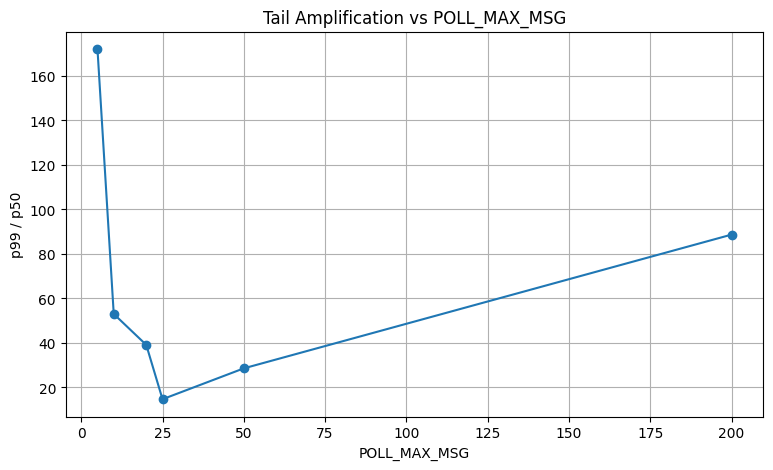

In [83]:
# =============================================================================
# 12. Plot: Tail amplification
# =============================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["poll_max_msg"],
    comparison_df["tail_amp_p99_p50"],
    marker="o"
)

plt.xlabel("POLL_MAX_MSG")
plt.ylabel("p99 / p50")
plt.title("Tail Amplification vs POLL_MAX_MSG")
plt.grid(True)

plt.savefig(
    FIG_DIR / "tail_amplification_vs_poll_max_msg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()